In [1]:
from utils import ASSETS_DIR
import torch
import torch.nn.functional as F
from models.quantum.quantumMap import quantumAnsatz, VQC
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch.nn as nn
from utils.models import load_all_skops
import torch.optim as optim
from sklearn.utils import resample

La root del progetto è: /home/kirjia/ProgettoQuantumBioetria/src


In [2]:
num_qubits = 6
dim = [4, 8, 16, 32]


objs = load_all_skops(ASSETS_DIR / "seeds_11") 
objs.pop('scaler')
pca32 = objs['pca_32']

dataset = pd.read_csv(ASSETS_DIR / "seeds_11/train_11.csv")
dataset = resample(dataset, n_samples=4000, random_state=11)
val = pd.read_csv(ASSETS_DIR / "seeds_11/val_11.csv")
X_train = dataset.drop(columns=["label"])
X_train = pca32.transform(X_train.values)
Y_train = dataset["label"]
X_val = val.drop(columns=["label"])
X_val = pca32.transform(X_val.values)
Y_val = val["label"]

scaler = MinMaxScaler(feature_range=(0, 2*np.pi))
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

tensor = torch.from_numpy(X_train).float()
tensor.size()
tensor_Y = torch.from_numpy(Y_train.values).long()

dataset_val = torch.utils.data.TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(Y_val.values).long())
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=32, shuffle=True, num_workers=6)



Caricamento di: scaler.skops...
scaler caricato con successo.
Caricamento di: pca_16.skops...
pca_16 caricato con successo.
Caricamento di: pca_4.skops...
pca_4 caricato con successo.
Caricamento di: pca_32.skops...
pca_32 caricato con successo.
Caricamento di: pca_8.skops...
pca_8 caricato con successo.


/tmp/ipykernel_2966/4025833544.py:25: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  tensor_Y = torch.from_numpy(Y_train.values).long()


Dimensione originale: 32, Zeri aggiunti: 4, Dimensione padded: 36


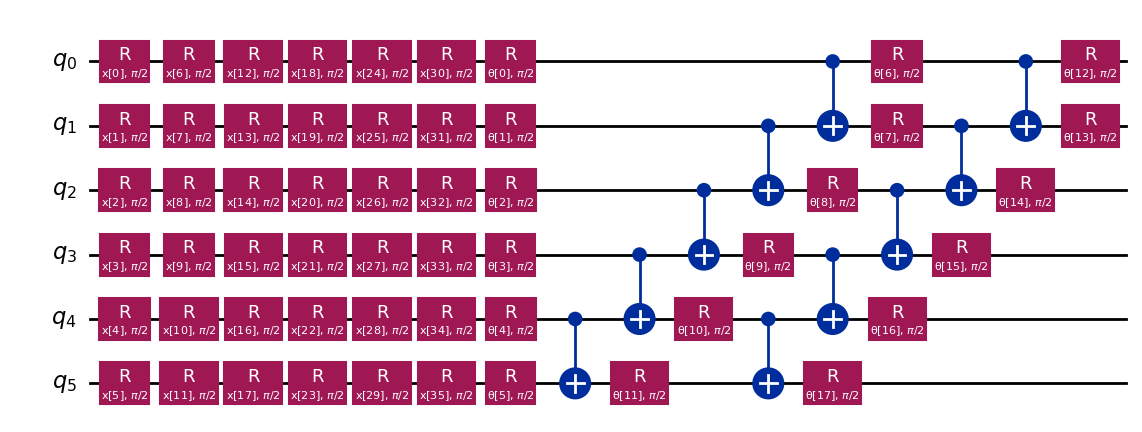

In [3]:
ansatz, d_padded, input_params, weight_params = quantumAnsatz(num_qubits, dim[3])
ansatz.decompose().draw("mpl")


In [ ]:
X_padded = F.pad(tensor, (0, d_padded - dim[3]), mode="constant", value=0.0)
dataset_train = torch.utils.data.TensorDataset(
    X_padded.float(),
    torch.from_numpy(Y_train.values).long()
)
print(f"Dataset train size: {dataset_train.__len__()} samples")
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=64, shuffle=False, num_workers=12, pin_memory=True)
print(f"DataLoader train size: {len(dataloader_train)} batches")


Dataset train size: 4000 samples
DataLoader train size: 63 batches


In [9]:

from qiskit.quantum_info import SparsePauliOp



observables = []
for i in range(num_qubits):
    # Mette una 'Z' sul qubit i, e l'identità 'I' su tutti gli altri
    obs = SparsePauliOp.from_sparse_list([("Z", [i], 1.0)], num_qubits=num_qubits)
    observables.append(obs)


quantum_model = VQC(num_qubits, dim[3], obs=observables)
quantum_model.to("cuda")

Dimensione originale: 32, Zeri aggiunti: 4, Dimensione padded: 36


VQC(
  (quantum_layer): TorchConnector()
  (linear): Linear(in_features=6, out_features=4, bias=True)
)

In [6]:
from torch.nn.utils import parameters_to_vector, vector_to_parameters

criterion = nn.CrossEntropyLoss()

def objective_function(weights_np):
    # Trasforma i numeri di Qiskit in tensori di PyTorch
    weights_tensor = torch.tensor(weights_np, dtype=torch.float32)
    vector_to_parameters(weights_tensor, [quantum_model.q_weights])
    
    # Prendi un batch dal tuo dataloader di PyTorch
    batch_X, batch_y = next(iter(dataloader_train))
    
    # Calcola l'errore
    with torch.no_grad():
        logits = quantum_model(batch_X)
        loss = criterion(logits, batch_y)
        
    return loss.item()

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(quantum_model.parameters(), lr=0.001)
epochs = 10
patience = 7
best_val_loss = float('inf')

In [ ]:
import time


for epoch in range(epochs):
    quantum_model.train()
    running_loss = 0.0
    start_time = time.time()
    
    # Il dataloader_train fornisce iterativamente i batch (es. da 32)
    for batch_X, batch_y in dataloader_train:
       

        batch_X = batch_X.to("cuda")
        batch_y = batch_y.to("cuda")
        
        # A. Azzeriamo i gradienti
        optimizer.zero_grad()
        
        # B. FORWARD PASS
        # Qui la QNN crea in automatico il PUB per l'intero batch e lo esegue
        logits = quantum_model(batch_X)
        
        # C. Calcolo della Loss
        loss = criterion(logits, batch_y)
        
        
        loss.backward()
        
        # E. Aggiornamento dei pesi
        optimizer.step()
        
        running_loss += loss.item()
        step_time = time.time() - start_time
        
    print(f"Tempo per epoca {epoch+1}: {step_time:.2f} secondi")
    
    loss_media = running_loss / len(dataloader_train)
    print(f"Epoca {epoch+1}/{epochs} - Loss: {loss_media:.4f}")

Batch processed in 3.12 seconds
Batch processed in 2.84 seconds
Batch processed in 3.05 seconds
Batch processed in 2.78 seconds
Batch processed in 2.82 seconds
Batch processed in 2.76 seconds
Batch processed in 2.92 seconds
Batch processed in 2.87 seconds
Batch processed in 2.80 seconds
Batch processed in 2.81 seconds
Batch processed in 2.97 seconds
Batch processed in 2.79 seconds
Batch processed in 2.80 seconds
Batch processed in 2.97 seconds
Batch processed in 2.81 seconds
Batch processed in 2.78 seconds
Batch processed in 2.78 seconds
Batch processed in 2.96 seconds
Batch processed in 2.79 seconds
Batch processed in 2.79 seconds
Batch processed in 2.81 seconds
Batch processed in 2.97 seconds
Batch processed in 2.81 seconds
Batch processed in 2.78 seconds
Batch processed in 2.78 seconds
Batch processed in 2.95 seconds
Batch processed in 2.79 seconds
Batch processed in 2.80 seconds
Batch processed in 2.95 seconds
Batch processed in 2.81 seconds
Batch processed in 2.78 seconds
Batch pr

In [ ]:
import time
from qiskit_machine_learning.optimizers import SPSA

for epoch in range(epochs):
    #quantum_model.train()
    running_loss = 0.0
    

    
    initial_weights = parameters_to_vector(quantum_model.q_weights).detach().cpu().numpy()
    spsa_optimizer = SPSA(maxiter=300)
    
    print("Allenamento con qiskit_machine_learning.optimizers.SPSA in corso...")
    t0 = time.time()
    
    result = spsa_optimizer.minimize(fun=objective_function, x0=initial_weights)
    best_weights = torch.tensor(result.x, dtype=torch.float32)
    vector_to_parameters(best_weights, [quantum_model.q_weights])
    print("Allenamento completato!")
    t1 = time.time()
    print(f"Tempo totale per l'epoca: {t1 - t0:.2f} secondi")
    
    # Stampa la loss media dell'epoca
    #loss_media = running_loss / len(dataloader_train)
    print(f"Epoca {epoch+1}/{epochs} - Loss: {result.x:.4f}")

In [ ]:
import torch
from torch.profiler import profile, record_function, ProfilerActivity

# Eseguiamo il profiling solo per 1 singolo batch per non rallentare tutto
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_stack=True # Ti dice quale riga di codice consuma tempo
) as prof:
    
    # Prendi solo il primo batch manualmente per il test
    batch_X, batch_y = next(iter(dataloader_train))
    
        
        
    with record_function("Forward QNN"):
        logits = quantum_model(batch_X)
        loss = criterion(logits, batch_y)
        
    with record_function("Backward QNN"):
        loss.backward()
        optimizer.step()

# Stampa i risultati nel terminale
print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=15))